In [71]:
import pandas as pd
import ast
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


sns.set(style="whitegrid")


In [72]:
tracks = pd.read_csv("./data/tracks.tsv", sep="\t")
echonest = pd.read_csv("./data/echonest_features.tsv", sep="\t")
spectral = pd.read_csv("./data/spectral_features.tsv", sep="\t")
genres = pd.read_csv("./data/genres.csv")

In [73]:
def clean_cols(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    return df

tracks = clean_cols(tracks)
echonest = clean_cols(echonest)
spectral = clean_cols(spectral)
genres = clean_cols(genres)


In [74]:
# Merge tracks + echonest
df = pd.merge(tracks, echonest, on="track_id", how="outer")

# Merge avec spectral
df = pd.merge(df, spectral, on="track_id", how="outer")

In [75]:
df.shape



(100882, 43)

In [76]:
df.describe(include="all").transpose().head(30)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,100882.0,NaN,NaN,NaN,83848.443449,41939.264125,11870.0,47333.25,83019.5,121348.75,155320.0
album_title,99084,13212,microSong Entries,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_tracks,99995.0,NaN,NaN,NaN,19.908645,40.510849,-1.0,7.0,11.0,18.0,652.0
artist_latitude,40207.0,NaN,NaN,NaN,39.967832,18.766913,-45.874501,39.271398,41.823989,50.079079,67.286005
artist_longitude,40207.0,NaN,NaN,NaN,-35.443236,65.670545,-157.526855,-78.868915,-72.669067,5.007986,175.277
artist_name,99995,15491,Kosta T,745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,99995.0,NaN,NaN,NaN,278.034522,294.940279,0.0,151.0,218.0,307.0,11030.0
favorites,99995.0,NaN,NaN,NaN,3.239962,13.863871,0.0,0.0,1.0,3.0,1482.0
genre_top,44633,16,Rock,12085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,99995,4652,[21],2527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
(df.isna().sum() / len(df) * 100).head(30)


track_id                           0.000000
album_title                        1.782280
album_tracks                       0.879245
artist_latitude                   60.144525
artist_longitude                  60.144525
artist_name                        0.879245
duration                           0.879245
favorites                          0.879245
genre_top                         55.757221
genres                             0.879245
genres_all                         0.879245
interest                           0.879245
listens                            0.879245
title                              0.880236
acousticness                      88.660019
danceability                      88.678853
energy                            88.660019
instrumentalness                  88.660019
liveness                          88.660019
speechiness                       88.808707
tempo                             88.660019
valence                           88.680835
spectral_bandwidth_kurtosis_01  

In [78]:
df.duplicated(subset=["track_id"]).sum()


np.int64(0)

In [79]:
df["genre_top"].value_counts(dropna=False)


genre_top
NaN                    56249
Rock                   12085
Experimental            9752
Electronic              8769
Hip-Hop                 3334
Folk                    2375
Pop                     2235
Instrumental            2003
International           1256
Classical               1129
Old-Time / Historic      491
Jazz                     484
Spoken                   323
Country                  163
Soul-RnB                 131
Blues                     79
Easy Listening            24
Name: count, dtype: int64

In [80]:
# Dicos à partir de genres.csv
id2parent = genres.set_index("genre_id")["genre_parent_id"].to_dict()
id2title  = genres.set_index("genre_id")["genre_title"].to_dict()
title2id  = genres.set_index("genre_title")["genre_id"].to_dict()

def get_root_title_from_id(gid):
    """À partir d'un genre_id (ex: 21), remonte jusqu'au genre racine et renvoie son titre."""
    if pd.isna(gid):
        return None
    try:
        gid = int(gid)
    except Exception:
        return None

    seen = set()
    while True:
        if gid in seen:  # sécurité anti-boucle
            return id2title.get(gid)
        seen.add(gid)

        parent = id2parent.get(gid)
        if parent is None or pd.isna(parent):
            # on est au niveau racine
            return id2title.get(gid)
        try:
            gid = int(parent)
        except Exception:
            return id2title.get(gid)

def first_id_to_root_title(s):
    """
    s est une string du type "[21, 33]" ou "[]".
    On prend le premier ID et on renvoie le *genre racine* correspondant.
    """
    if isinstance(s, float) and math.isnan(s):
        return None
    if not isinstance(s, str):
        return None
    try:
        ids = ast.literal_eval(s)   # -> [21, 33]
        if not ids:
            return None
        first_id = ids[0]
        return get_root_title_from_id(first_id)
    except Exception:
        return None

# colonnes temporaires pour l’imputation
df["genre_top_from_genres"] = df["genres"].apply(first_id_to_root_title)
df["genre_top_from_genres_all"] = df["genres_all"].apply(first_id_to_root_title)

print("Taux de NaN genre_top AVANT :", df["genre_top"].isna().mean())

# imputation de genre_top avec les genres *racines*
df["genre_top"] = df["genre_top"].fillna(df["genre_top_from_genres"])
df["genre_top"] = df["genre_top"].fillna(df["genre_top_from_genres_all"])

print("Taux de NaN genre_top APRES  :", df["genre_top"].isna().mean())

# on enlève les colonnes temporaires
df = df.drop(columns=["genre_top_from_genres", "genre_top_from_genres_all"])


Taux de NaN genre_top AVANT : 0.5575722130806289
Taux de NaN genre_top APRES  : 0.029985527646160862


In [81]:
nan_ratio = df.isna().mean().sort_values(ascending=False)
nan_ratio


speechiness                       0.888087
valence                           0.886808
danceability                      0.886789
instrumentalness                  0.886600
energy                            0.886600
tempo                             0.886600
liveness                          0.886600
acousticness                      0.886600
artist_latitude                   0.601445
artist_longitude                  0.601445
genre_top                         0.029986
album_title                       0.017823
title                             0.008802
favorites                         0.008792
genres_all                        0.008792
artist_name                       0.008792
duration                          0.008792
album_tracks                      0.008792
genres                            0.008792
spectral_bandwidth_skew_01        0.008792
interest                          0.008792
listens                           0.008792
spectral_bandwidth_kurtosis_01    0.008792
spectral_ba

In [82]:
low_thresh = 0.01   # <1% NaN → imputation
high_thresh = 0.50  # >50% NaN → potentiellement à drop

cols_low_nan = nan_ratio[nan_ratio < low_thresh].index.tolist()
cols_high_nan = nan_ratio[nan_ratio > high_thresh].index.tolist()

print("Colonnes <1% NaN :", len(cols_low_nan))
print("Colonnes >50% NaN :", len(cols_high_nan))
cols_low_nan, cols_high_nan


Colonnes <1% NaN : 31
Colonnes >50% NaN : 10


(['title',
  'favorites',
  'genres_all',
  'artist_name',
  'duration',
  'album_tracks',
  'genres',
  'spectral_bandwidth_skew_01',
  'interest',
  'listens',
  'spectral_bandwidth_kurtosis_01',
  'spectral_bandwidth_max_01',
  'spectral_bandwidth_mean_01',
  'spectral_bandwidth_median_01',
  'spectral_bandwidth_min_01',
  'spectral_centroid_std_01',
  'spectral_bandwidth_std_01',
  'spectral_centroid_kurtosis_01',
  'spectral_centroid_max_01',
  'spectral_centroid_mean_01',
  'spectral_centroid_median_01',
  'spectral_centroid_min_01',
  'spectral_centroid_skew_01',
  'spectral_rolloff_median_01',
  'spectral_rolloff_kurtosis_01',
  'spectral_rolloff_max_01',
  'spectral_rolloff_mean_01',
  'spectral_rolloff_skew_01',
  'spectral_rolloff_min_01',
  'spectral_rolloff_std_01',
  'track_id'],
 ['speechiness',
  'valence',
  'danceability',
  'instrumentalness',
  'energy',
  'tempo',
  'liveness',
  'acousticness',
  'artist_latitude',
  'artist_longitude'])

In [83]:
echonest_cols = [
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "speechiness", "tempo", "valence"
]

# colonnes qu’on protège même si beaucoup de NaN
protected_cols = set(echonest_cols + ["genre_top"])

# colonnes très manquantes à drop (ex: artist_latitude, artist_longitude)
high_missing_to_drop = [c for c in cols_high_nan if c not in protected_cols]

high_missing_to_drop


['artist_latitude', 'artist_longitude']

In [84]:
df_clean = df.drop(columns=high_missing_to_drop).copy()

nan_ratio_clean = df_clean.isna().mean()
cols_low_nan_clean = nan_ratio_clean[nan_ratio_clean < low_thresh].index

for col in cols_low_nan_clean:
    if df_clean[col].dtype != "object":
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isna().mean().sort_values(ascending=False).head(20)


speechiness         0.888087
valence             0.886808
danceability        0.886789
instrumentalness    0.886600
liveness            0.886600
acousticness        0.886600
energy              0.886600
tempo               0.886600
genre_top           0.029986
album_title         0.017823
genres_all          0.000000
favorites           0.000000
genres              0.000000
album_tracks        0.000000
artist_name         0.000000
track_id            0.000000
duration            0.000000
listens             0.000000
interest            0.000000
title               0.000000
dtype: float64

In [85]:
# Sans echonest
df_no_echonest = df_clean.drop(columns=[c for c in echonest_cols if c in df_clean.columns])
print("df_no_echonest:", df_no_echonest.shape)

# Avec echonest
df_with_echonest = df_clean.copy()
print("df_with_echonest:", df_with_echonest.shape)


df_no_echonest: (100882, 33)
df_with_echonest: (100882, 41)


In [86]:
df_no_echonest_clf = df_no_echonest[~df_no_echonest["genre_top"].isna()].copy()
df_with_echonest_clf = df_with_echonest[~df_with_echonest["genre_top"].isna()].copy()

print("Classification sans echonest:", df_no_echonest_clf.shape)
print("Classification avec echonest:", df_with_echonest_clf.shape)


Classification sans echonest: (97857, 33)
Classification avec echonest: (97857, 41)


In [87]:
text_cols = ["album_title", "title", "artist_name"]

df_no_echonest_clf = df_no_echonest_clf.drop(columns=text_cols + ["track_id"], errors="ignore")
df_with_echonest_clf = df_with_echonest_clf.drop(columns=text_cols + ["track_id"], errors="ignore")

print("df_no_echonest_clf:", df_no_echonest_clf.shape)
print("df_with_echonest_clf:", df_with_echonest_clf.shape)


df_no_echonest_clf: (97857, 29)
df_with_echonest_clf: (97857, 37)


In [88]:
df_no_echonest_clf_fe = df_no_echonest_clf.copy()
df_with_echonest_clf_fe = df_with_echonest_clf.copy()


In [89]:
log_vars = ["listens", "interest", "favorites"]

for col in log_vars:
    if col in df_no_echonest_clf_fe.columns:
        df_no_echonest_clf_fe[col + "_log1p"] = np.log1p(df_no_echonest_clf_fe[col])
    if col in df_with_echonest_clf_fe.columns:
        df_with_echonest_clf_fe[col + "_log1p"] = np.log1p(df_with_echonest_clf_fe[col])

In [90]:
def add_popularity_score_log(df):
    # log1p transform
    df["listens_log"] = np.log1p(df["listens"])
    df["interest_log"] = np.log1p(df["interest"])
    df["favorites_log"] = np.log1p(df["favorites"])

    # normalisation min-max
    for col in ["listens_log", "interest_log", "favorites_log"]:
        df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    # moyenne après normalisation
    df["popularity_score"] = df[[
        "listens_log_norm",
        "interest_log_norm",
        "favorites_log_norm"
    ]].mean(axis=1)

    return df

df_no_echonest_clf_fe = add_popularity_score_log(df_no_echonest_clf_fe)
df_with_echonest_clf_fe = add_popularity_score_log(df_with_echonest_clf_fe)


In [91]:
bins = [0, 150, 300, df_no_echonest_clf_fe["duration"].max()]
labels = ["short", "medium", "long"]

df_no_echonest_clf_fe["duration_bin"] = pd.cut(
    df_no_echonest_clf_fe["duration"], bins=bins, labels=labels, include_lowest=True
)

df_with_echonest_clf_fe["duration_bin"] = pd.cut(
    df_with_echonest_clf_fe["duration"], bins=bins, labels=labels, include_lowest=True
)


In [92]:
# produit energy*danceability
if all(c in df_with_echonest_clf_fe.columns for c in ["energy", "danceability"]):
    df_with_echonest_clf_fe["energy_x_danceability"] = (
        df_with_echonest_clf_fe["energy"] * df_with_echonest_clf_fe["danceability"]
    )

# ratio acousticness/instrumentalness
if all(c in df_with_echonest_clf_fe.columns for c in ["acousticness", "instrumentalness"]):
    df_with_echonest_clf_fe["acoustic_instrumental_ratio"] = (
        df_with_echonest_clf_fe["acousticness"] / (df_with_echonest_clf_fe["instrumentalness"] + 1e-6)
    )

# log tempo
if "tempo" in df_with_echonest_clf_fe.columns:
    df_with_echonest_clf_fe["tempo_log1p"] = np.log1p(df_with_echonest_clf_fe["tempo"])


c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


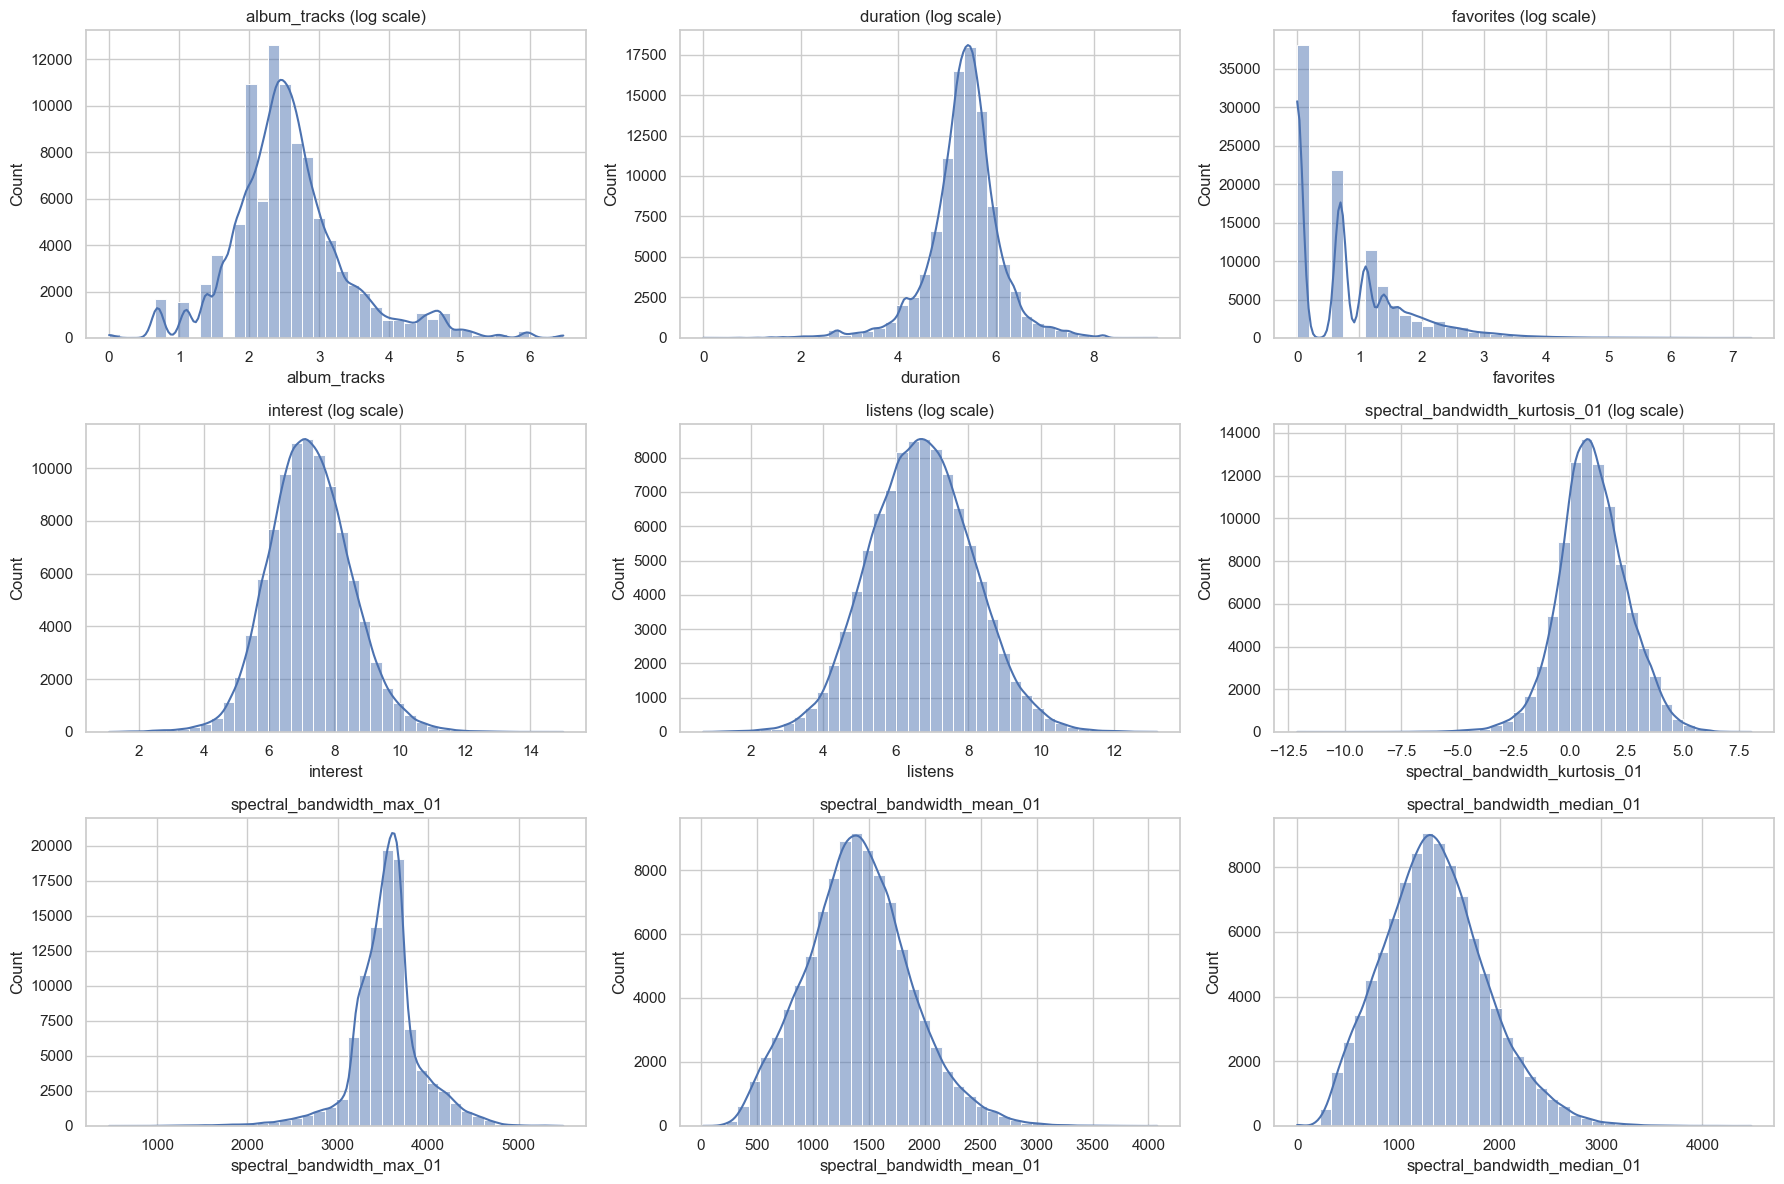

In [93]:
def plot_numeric_distributions(df, cols, n_cols=3, bins=40):
    n = len(cols)
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(6*n_cols, 4*n_rows))

    for i, col in enumerate(cols):
        data = df[col].dropna()

        # détecter skew
        skewness = data.skew()

        plt.subplot(n_rows, n_cols, i+1)

        # si skew > 2 → affichage en log
        if skewness > 2:
            sns.histplot(np.log1p(data), bins=bins, kde=True)
            plt.title(f"{col} (log scale)")
        else:
            sns.histplot(data, bins=bins, kde=True)
            plt.title(col)

    plt.tight_layout()
    plt.show()

numeric_cols = df_no_echonest_clf_fe.select_dtypes(include=["float64", "int64"]).columns.tolist()

# on enlève track_id, norms, etc.
numeric_cols = [c for c in numeric_cols 
                if not c.endswith("_norm")
                and c not in ["track_id"]]

plot_numeric_distributions(df_no_echonest_clf_fe, numeric_cols[:9])


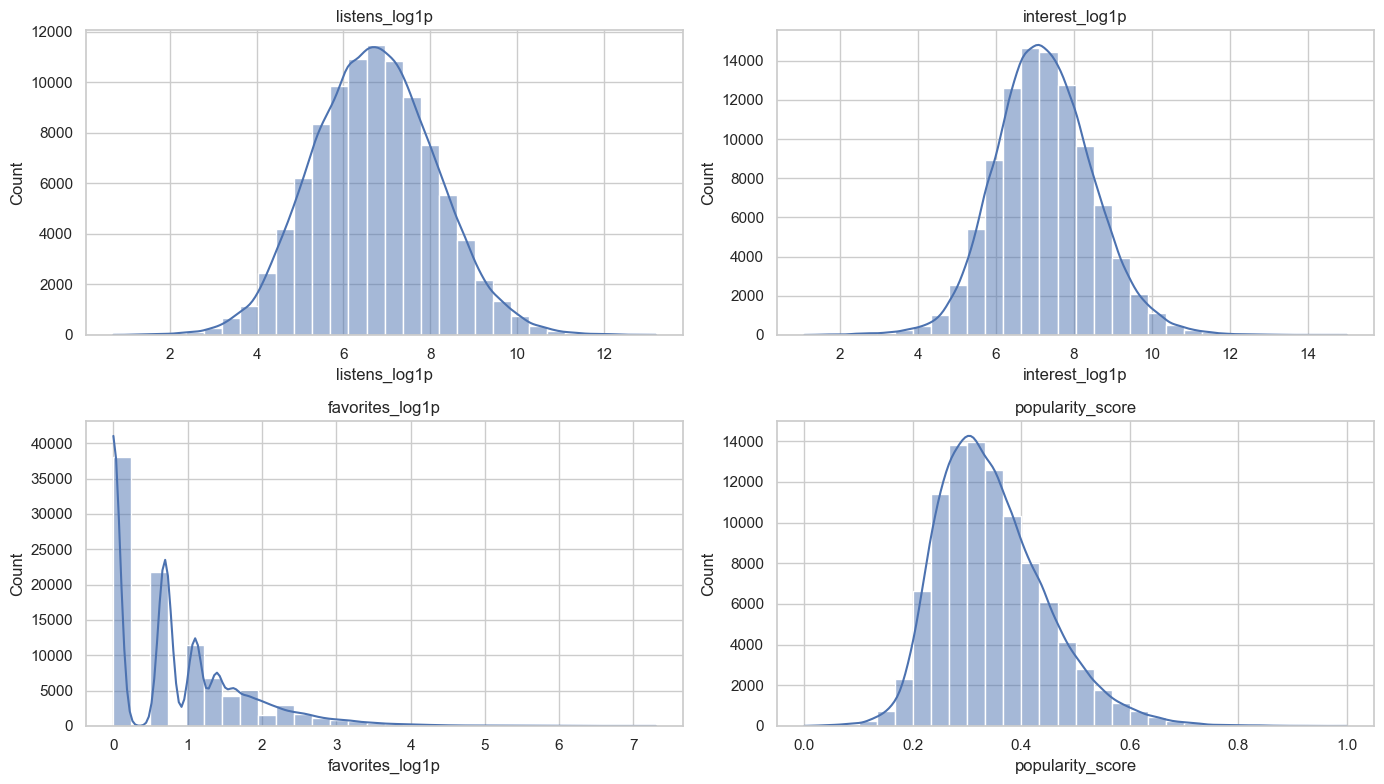

In [94]:
cols_pop = ["listens_log1p", "interest_log1p", "favorites_log1p", "popularity_score"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(cols_pop):
    if col in df_no_echonest_clf_fe.columns:
        plt.subplot(2, 2, i+1)
        sns.histplot(df_no_echonest_clf_fe[col], kde=True, bins=30)
        plt.title(col)
plt.tight_layout()
plt.show()


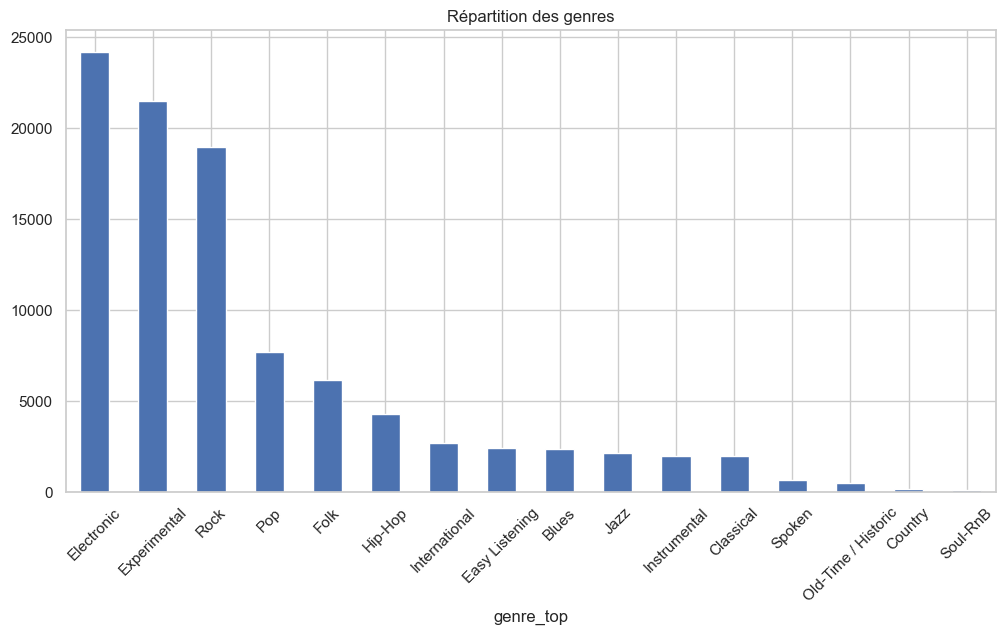

In [95]:
plt.figure(figsize=(12, 6))
df_no_echonest_clf_fe["genre_top"].value_counts().plot(kind="bar")
plt.title("Répartition des genres")
plt.xticks(rotation=45)
plt.show()


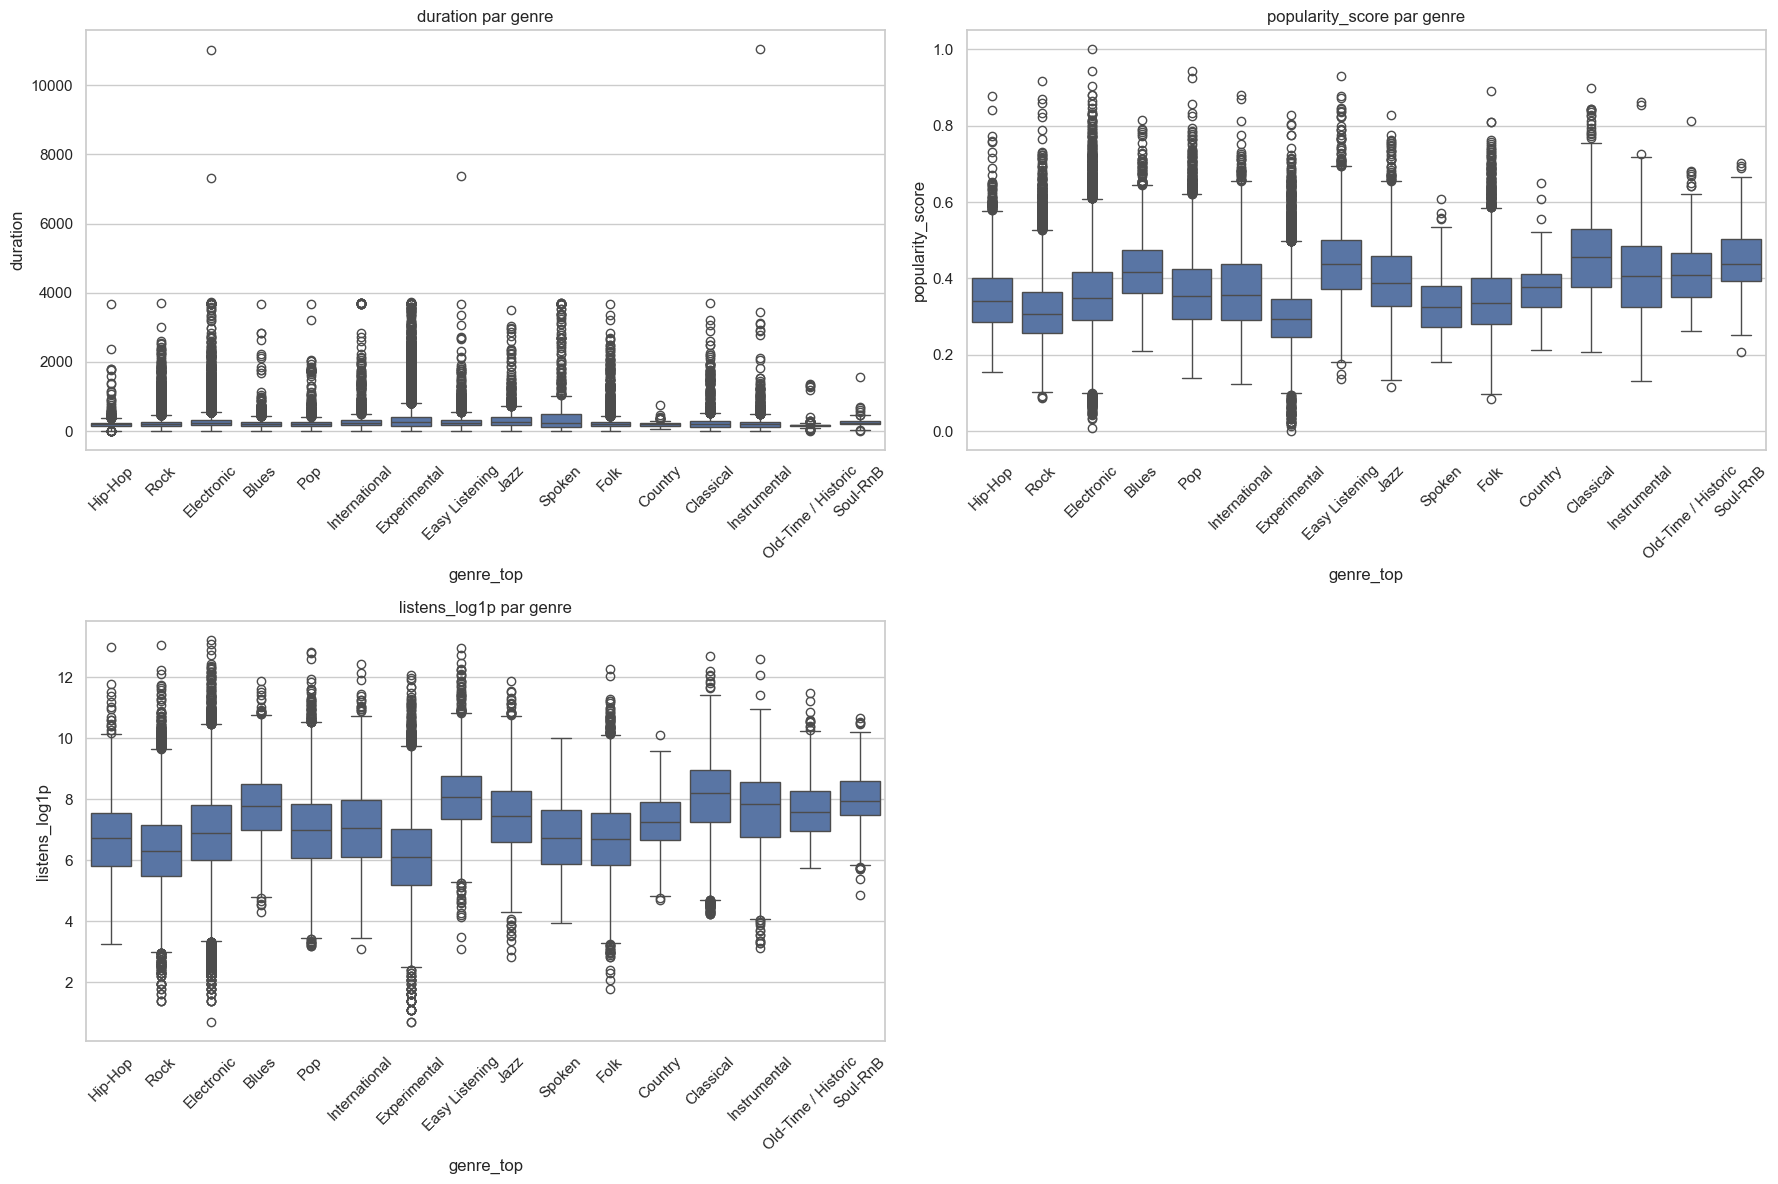

In [96]:
plt.figure(figsize=(18, 12))

cols_to_compare = ["duration", "popularity_score", "listens_log1p"]

for i, col in enumerate(cols_to_compare):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df_no_echonest_clf_fe, x="genre_top", y=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} par genre")
plt.tight_layout()
plt.show()


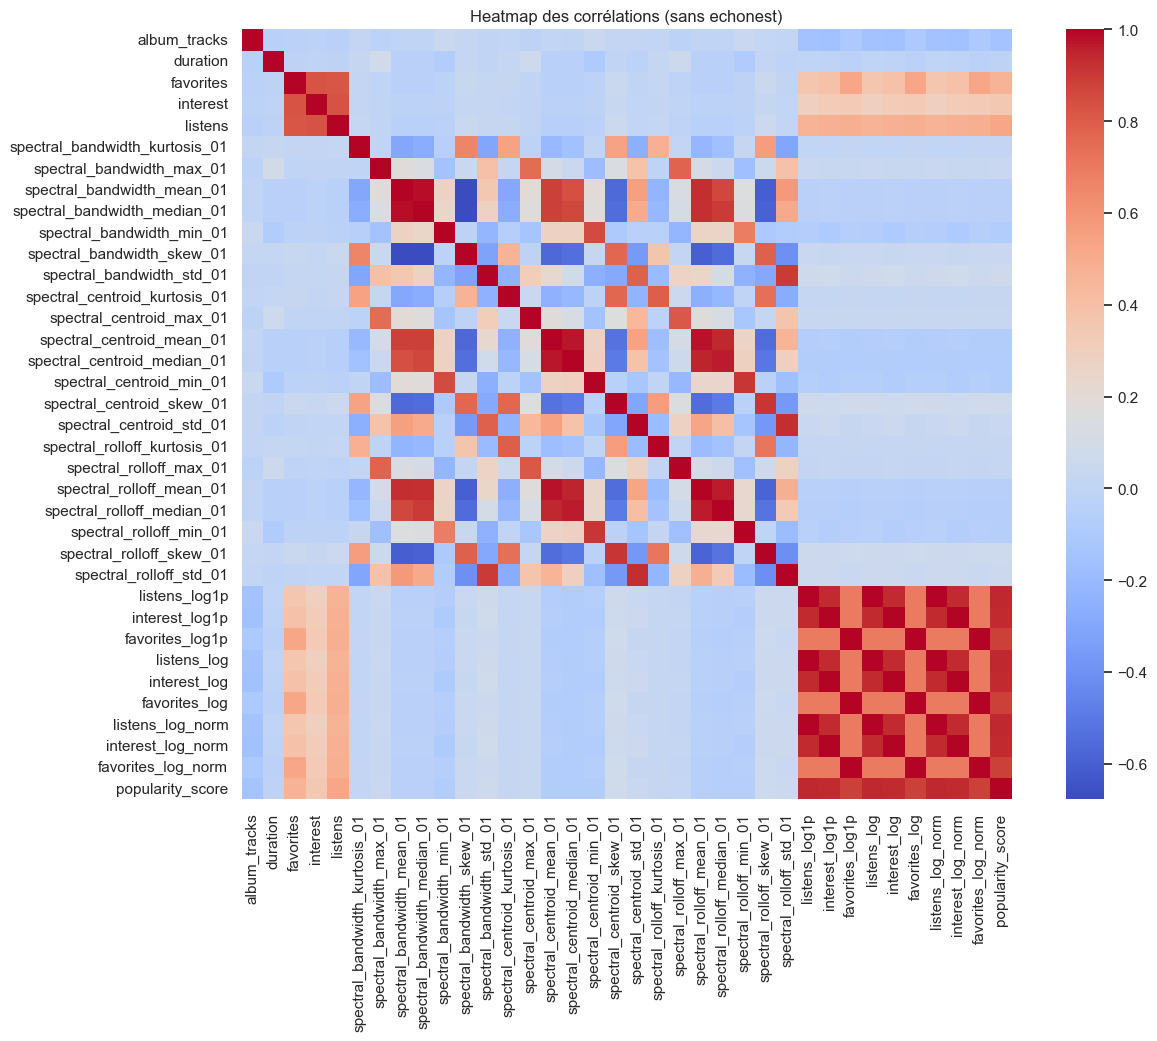

In [97]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_no_echonest_clf_fe.corr(numeric_only=True),
    cmap="coolwarm",
    square=True
)
plt.title("Heatmap des corrélations (sans echonest)")
plt.show()


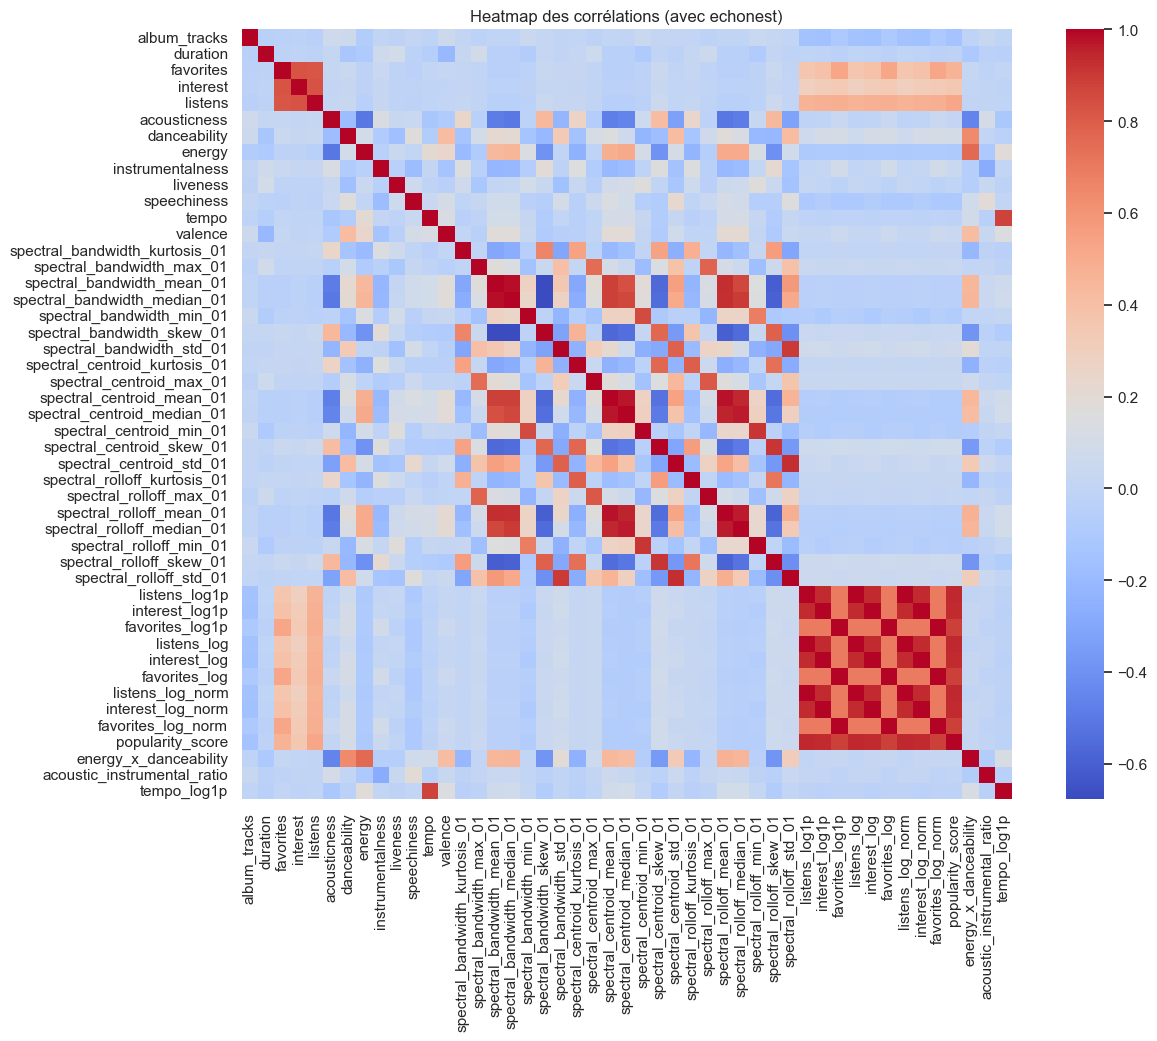

In [98]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_with_echonest_clf_fe.corr(numeric_only=True),
    cmap="coolwarm",
    square=True
)
plt.title("Heatmap des corrélations (avec echonest)")
plt.show()


In [118]:
macro_mapping = {
    "Classical": "Classical/Jazz",
    "Jazz": "Classical/Jazz",

    "Rock": "Rock/Pop",
    "Pop": "Rock/Pop",
    "Soul-RnB": "Rock/Pop",
    "Hip-Hop": "Rock/Pop",   # Ajouter Hip-Hop ici pour éviter NaN

    "Electronic": "Electronic",

    "Folk": "Folk/Country/Blues",
    "Country": "Folk/Country/Blues",
    "Blues": "Folk/Country/Blues",

    "Experimental": "Experimental",
    "Instrumental": "Experimental",
    "Ambient": "Experimental",
    "Spoken": "Experimental",
    "International": "Experimental",
    "Easy Listening": "Experimental",
    "Old-Time / Historic": "Experimental"
}


In [119]:
# On repart de df_no_echonest_clf_fe et df_with_echonest_clf_fe
drop_cols = [
    "track_id", "genre_top", "duration_bin", "subset", "subset_ord",
    "split", "is_train_split", "album_title", "title", "artist_name",
    "genres", "genres_all"  # 🔴 on les enlève maintenant
]

drop_cols += [c for c in df_no_echonest_clf_fe.columns if c.endswith("_norm")]

df_no_echo = df_no_echonest_clf_fe.drop(columns=drop_cols, errors="ignore")
df_with_echo = df_with_echonest_clf_fe.drop(columns=drop_cols, errors="ignore")

# 🔐 On garde UNIQUEMENT les colonnes numériques
X_no_echo_T1  = df_no_echo.select_dtypes(include=[np.number])
X_with_echo_T1 = df_with_echo.select_dtypes(include=[np.number])

y_T1 = df_no_echonest_clf_fe["genre_top"]

In [120]:
# Task 1 (genres racines)
y_T1 = df_no_echonest_clf_fe["genre_top"]

# Task 2 (macro-genres)
y_T2 = df_no_echonest_clf_fe["genre_top"].map(macro_mapping)


In [121]:
y_T1_echo = df_with_echonest_clf_fe["genre_top"]
y_T2_echo = df_with_echonest_clf_fe["genre_top"].map(macro_mapping)


In [122]:
X_no_echo_T1 = df_no_echo.copy()
X_with_echo_T1 = df_with_echo.copy()

X_no_echo_T2 = df_no_echo.copy()
X_with_echo_T2 = df_with_echo.copy()


In [123]:
print("Task 1 — NO echo:", X_no_echo_T1.shape, y_T1.shape)
print("Task 1 — WITH echo:", X_with_echo_T1.shape, y_T1_echo.shape)

print("Task 2 — NO echo:", X_no_echo_T2.shape, y_T2.shape)
print("Task 2 — WITH echo:", X_with_echo_T2.shape, y_T2_echo.shape)


Task 1 — NO echo: (97857, 33) (97857,)
Task 1 — WITH echo: (97857, 44) (97857,)
Task 2 — NO echo: (97857, 33) (97857,)
Task 2 — WITH echo: (97857, 44) (97857,)


In [124]:
# Base pour le split maître
X = X_no_echo_T1
y = y_T1

# 1) Train+Val vs Test (20% test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2) Train vs Val (20% de trainval -> 0.2 * 0.8 = 16% du total en val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_trainval
)

print("Shapes Task 1 / no echo (split maître) :")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)


Shapes Task 1 / no echo (split maître) :
X_train : (62628, 33)
X_val   : (15657, 33)
X_test  : (19572, 33)


In [125]:
train_idx = X_train.index
val_idx   = X_val.index
test_idx  = X_test.index

len(train_idx), len(val_idx), len(test_idx)


(62628, 15657, 19572)

In [126]:
# Task 1 — NO echonest
X_train_no_echo_T1 = X_no_echo_T1.loc[train_idx]
X_val_no_echo_T1   = X_no_echo_T1.loc[val_idx]
X_test_no_echo_T1  = X_no_echo_T1.loc[test_idx]

y_train_T1 = y_T1.loc[train_idx]
y_val_T1   = y_T1.loc[val_idx]
y_test_T1  = y_T1.loc[test_idx]

# Task 1 — WITH echonest
X_train_with_echo_T1 = X_with_echo_T1.loc[train_idx]
X_val_with_echo_T1   = X_with_echo_T1.loc[val_idx]
X_test_with_echo_T1  = X_with_echo_T1.loc[test_idx]

# y_T1_echo est identique à y_T1 (mêmes morceaux, mêmes labels), donc :
y_train_T1_echo = y_train_T1.copy()
y_val_T1_echo   = y_val_T1.copy()
y_test_T1_echo  = y_test_T1.copy()

print("Task 1 — NO echo train/val/test :", X_train_no_echo_T1.shape, X_val_no_echo_T1.shape, X_test_no_echo_T1.shape)
print("Task 1 — WITH echo train/val/test :", X_train_with_echo_T1.shape, X_val_with_echo_T1.shape, X_test_with_echo_T1.shape)


Task 1 — NO echo train/val/test : (62628, 33) (15657, 33) (19572, 33)
Task 1 — WITH echo train/val/test : (62628, 44) (15657, 44) (19572, 44)


In [127]:
# Task 2 — NO echonest
X_train_no_echo_T2 = X_no_echo_T2.loc[train_idx]
X_val_no_echo_T2   = X_no_echo_T2.loc[val_idx]
X_test_no_echo_T2  = X_no_echo_T2.loc[test_idx]

y_train_T2 = y_T2.loc[train_idx]
y_val_T2   = y_T2.loc[val_idx]
y_test_T2  = y_T2.loc[test_idx]

# Task 2 — WITH echonest
X_train_with_echo_T2 = X_with_echo_T2.loc[train_idx]
X_val_with_echo_T2   = X_with_echo_T2.loc[val_idx]
X_test_with_echo_T2  = X_with_echo_T2.loc[test_idx]

y_train_T2_echo = y_T2_echo.loc[train_idx]
y_val_T2_echo   = y_T2_echo.loc[val_idx]
y_test_T2_echo  = y_T2_echo.loc[test_idx]

print("Task 2 — NO echo train/val/test :", X_train_no_echo_T2.shape, X_val_no_echo_T2.shape, X_test_no_echo_T2.shape)
print("Task 2 — WITH echo train/val/test :", X_train_with_echo_T2.shape, X_val_with_echo_T2.shape, X_test_with_echo_T2.shape)


Task 2 — NO echo train/val/test : (62628, 33) (15657, 33) (19572, 33)
Task 2 — WITH echo train/val/test : (62628, 44) (15657, 44) (19572, 44)


In [128]:
print("Répartition genres Task 1 — global :")
print(y_T1.value_counts(normalize=True).sort_index(), "\n")

print("Train :")
print(y_train_T1.value_counts(normalize=True).sort_index(), "\n")

print("Val :")
print(y_val_T1.value_counts(normalize=True).sort_index(), "\n")

print("Test :")
print(y_test_T1.value_counts(normalize=True).sort_index())


Répartition genres Task 1 — global :
genre_top
Blues                  0.024239
Classical              0.020397
Country                0.001666
Easy Listening         0.024893
Electronic             0.247003
Experimental           0.219340
Folk                   0.062826
Hip-Hop                0.044064
Instrumental           0.020469
International          0.027489
Jazz                   0.022226
Old-Time / Historic    0.005018
Pop                    0.078707
Rock                   0.193629
Soul-RnB               0.001339
Spoken                 0.006693
Name: proportion, dtype: float64 

Train :
genre_top
Blues                  0.024238
Classical              0.020406
Country                0.001661
Easy Listening         0.024893
Electronic             0.247014
Experimental           0.219343
Folk                   0.062815
Hip-Hop                0.044070
Instrumental           0.020470
International          0.027496
Jazz                   0.022226
Old-Time / Historic    0.005014
Pop 

In [110]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        class_weight="balanced",
        max_iter=200
    ))
])

pipe_lr.fit(X_train_no_echo_T1, y_train_T1)

y_pred_lr_val = pipe_lr.predict(X_val_no_echo_T1)

print("=== Logistic Regression (NO Echonest) — Validation ===")
print("Accuracy :", accuracy_score(y_val_T1, y_pred_lr_val))
print("F1 macro :", f1_score(y_val_T1, y_pred_lr_val, average="macro"))
print("F1 weighted :", f1_score(y_val_T1, y_pred_lr_val, average="weighted"))
print("\nClassification report :\n")
print(classification_report(y_val_T1, y_pred_lr_val))


c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression (NO Echonest) — Validation ===
Accuracy : 0.21894360350003195
F1 macro : 0.16731024087134475
F1 weighted : 0.24663523534543103

Classification report :

                     precision    recall  f1-score   support

              Blues       0.13      0.28      0.18       380
          Classical       0.15      0.46      0.22       319
            Country       0.01      0.65      0.02        26
     Easy Listening       0.11      0.18      0.13       390
         Electronic       0.53      0.12      0.20      3867
       Experimental       0.48      0.23      0.31      3434
               Folk       0.16      0.17      0.17       984
            Hip-Hop       0.21      0.46      0.29       690
       Instrumental       0.07      0.18      0.11       320
      International       0.06      0.06      0.06       430
               Jazz       0.07      0.06      0.06       348
Old-Time / Historic       0.23      0.90      0.37        79
                Pop       0.2

In [111]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_no_echo_T1, y_train_T1)
y_pred_rf_val = rf.predict(X_val_no_echo_T1)

print("=== Random Forest (NO Echonest) — Validation ===")
print("Accuracy :", accuracy_score(y_val_T1, y_pred_rf_val))
print("F1 macro :", f1_score(y_val_T1, y_pred_rf_val, average="macro"))
print("F1 weighted :", f1_score(y_val_T1, y_pred_rf_val, average="weighted"))
print("\nClassification report :\n")
print(classification_report(y_val_T1, y_pred_rf_val))


=== Random Forest (NO Echonest) — Validation ===
Accuracy : 0.4615826786740755
F1 macro : 0.28545497272025844
F1 weighted : 0.421395209980758

Classification report :

                     precision    recall  f1-score   support

              Blues       0.74      0.20      0.31       380
          Classical       0.61      0.43      0.50       319
            Country       0.00      0.00      0.00        26
     Easy Listening       0.37      0.10      0.16       390
         Electronic       0.43      0.71      0.53      3867
       Experimental       0.47      0.57      0.52      3434
               Folk       0.48      0.16      0.24       984
            Hip-Hop       0.65      0.18      0.28       690
       Instrumental       0.48      0.12      0.19       320
      International       0.62      0.06      0.11       430
               Jazz       0.86      0.05      0.10       348
Old-Time / Historic       0.82      0.84      0.83        79
                Pop       0.49      0.

c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [112]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T1.unique()),
    class_weight="balanced",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=50,
    random_state=42
)

lgb_model.fit(X_train_no_echo_T1, y_train_T1)
y_pred_lgb_val = lgb_model.predict(X_val_no_echo_T1)

print("=== LightGBM (NO Echonest) — Validation ===")
print("Accuracy :", accuracy_score(y_val_T1, y_pred_lgb_val))
print("F1 macro :", f1_score(y_val_T1, y_pred_lgb_val, average="macro"))
print("F1 weighted :", f1_score(y_val_T1, y_pred_lgb_val, average="weighted"))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7899
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 33
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM

In [113]:
y_T2.value_counts(normalize=True)


genre_top
Experimental/Instrumental/Ambient    0.317911
Rock/Pop                             0.286290
Electronic                           0.258389
Folk/Country/Blues                   0.092822
Classical/Jazz                       0.044588
Name: proportion, dtype: float64

In [129]:
pipe_lr_T2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=300
    ))
])

pipe_lr_T2.fit(X_train_no_echo_T2, y_train_T2)
y_pred_lr_T2 = pipe_lr_T2.predict(X_val_no_echo_T2)

print("=== Logistic Regression — Task 2 (NO Echonest) ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_lr_T2))
print("F1 macro :", f1_score(y_val_T2, y_pred_lr_T2, average="macro"))
print("\nReport :\n")
print(classification_report(y_val_T2, y_pred_lr_T2))


=== Logistic Regression — Task 2 (NO Echonest) ===
Accuracy : 0.39279555470396627
F1 macro : 0.3565187783192135

Report :

                    precision    recall  f1-score   support

    Classical/Jazz       0.14      0.51      0.22       667
        Electronic       0.45      0.42      0.44      3867
      Experimental       0.53      0.32      0.40      4758
Folk/Country/Blues       0.19      0.37      0.25      1390
          Rock/Pop       0.53      0.43      0.48      4975

          accuracy                           0.39     15657
         macro avg       0.37      0.41      0.36     15657
      weighted avg       0.47      0.39      0.41     15657



In [130]:
rf_T2 = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_T2.fit(X_train_no_echo_T2, y_train_T2)
y_pred_rf_T2 = rf_T2.predict(X_val_no_echo_T2)

print("=== Random Forest — Task 2 (NO Echonest) ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_rf_T2))
print("F1 macro :", f1_score(y_val_T2, y_pred_rf_T2, average="macro"))
print("\nReport :\n")
print(classification_report(y_val_T2, y_pred_rf_T2))


=== Random Forest — Task 2 (NO Echonest) ===
Accuracy : 0.5395030976560005
F1 macro : 0.4457388514034039

Report :

                    precision    recall  f1-score   support

    Classical/Jazz       0.75      0.20      0.31       667
        Electronic       0.54      0.50      0.52      3867
      Experimental       0.53      0.61      0.56      4758
Folk/Country/Blues       0.59      0.15      0.24      1390
          Rock/Pop       0.54      0.66      0.59      4975

          accuracy                           0.54     15657
         macro avg       0.59      0.42      0.45     15657
      weighted avg       0.55      0.54      0.52     15657



In [131]:
lgb_T2 = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T2.unique()),
    class_weight="balanced",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=50,
    random_state=42
)

lgb_T2.fit(X_train_no_echo_T2, y_train_T2)
y_pred_lgb_T2 = lgb_T2.predict(X_val_no_echo_T2)

print("=== LightGBM — Task 2 (NO Echonest) ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_lgb_T2))
print("F1 macro :", f1_score(y_val_T2, y_pred_lgb_T2, average="macro"))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7899
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 33
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
=== LightGBM — Task 2 (NO Echonest) ===
Accuracy : 0.5534904515552149
F1 macro : 0.5119560960875053


In [135]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

lgb_T1_echo = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T1_echo.unique()),
    class_weight="balanced",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=60,
    random_state=42,
    n_jobs=-1
)

# Training
lgb_T1_echo.fit(X_train_with_echo_T1, y_train_T1_echo)

# Predictions
y_pred_T1_echo = lgb_T1_echo.predict(X_val_with_echo_T1)

print("=== LightGBM — Task 1 (WITH Echonest) ===")
print("Accuracy :", accuracy_score(y_val_T1_echo, y_pred_T1_echo))
print("F1 macro :", f1_score(y_val_T1_echo, y_pred_T1_echo, average="macro"))
print("F1 weighted :", f1_score(y_val_T1_echo, y_pred_T1_echo, average="weighted"))

print("\nReport :\n")
print(classification_report(y_val_T1_echo, y_pred_T1_echo))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10704
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 44
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.77258

c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cyril\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [132]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

lgbm_T2_echo = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    class_weight="balanced",
    random_state=42
)

# Entraînement sur Task 2, AVEC Echonest
lgbm_T2_echo.fit(X_train_with_echo_T2, y_train_T2_echo)

# Validation
y_pred_lgbm_T2_echo = lgbm_T2_echo.predict(X_val_with_echo_T2)

acc = accuracy_score(y_val_T2_echo, y_pred_lgbm_T2_echo)
f1_macro = f1_score(y_val_T2_echo, y_pred_lgbm_T2_echo, average="macro")
f1_weighted = f1_score(y_val_T2_echo, y_pred_lgbm_T2_echo, average="weighted")

print("=== LightGBM — Task 2 (WITH Echonest) ===")
print("Accuracy :", acc)
print("F1 macro :", f1_macro)
print("F1 weighted :", f1_weighted)
print("\nReport :\n")
print(classification_report(y_val_T2_echo, y_pred_lgbm_T2_echo))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004910 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10704
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 44
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
=== LightGBM — Task 2 (WITH Echonest) ===
Accuracy : 0.5624321389793703
F1 macro : 0.5207750635895743
F1 weighted : 0.5705824208977831

Report :

                    precision    recall  f1-score   support

    Classical/Jazz       0.34      0.55      0.42       667
        Electronic       0.58      0.58      0.58      3867
      Experimental       0.64      0.56      0.60

In [138]:
from sklearn.impute import SimpleImputer

echonest_cols = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "speechiness",
    "tempo", "valence"
]

# copie
X_with_echo_T2_imp = X_with_echo_T2.copy()

# Missing indicators
for col in echonest_cols:
    X_with_echo_T2_imp[col + "_missing"] = X_with_echo_T2_imp[col].isna().astype(int)

# Imputation
imp = SimpleImputer(strategy="median")
X_with_echo_T2_imp[echonest_cols] = imp.fit_transform(X_with_echo_T2[echonest_cols])

# Splits
X_train_T2_imp = X_with_echo_T2_imp.loc[train_idx]
X_val_T2_imp   = X_with_echo_T2_imp.loc[val_idx]

# Train LGBM
lgb_T2_imp = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T2.unique()),
    class_weight="balanced",
    n_estimators=800,
    learning_rate=0.04,
    random_state=42
)

lgb_T2_imp.fit(X_train_T2_imp, y_train_T2)
y_pred_imp = lgb_T2_imp.predict(X_val_T2_imp)

print("=== AXE 2 LightGBM — T2 WITH IMPUTATION ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_imp))
print("F1 macro :", f1_score(y_val_T2, y_pred_imp, average='macro'))
print("F1 weighted :", f1_score(y_val_T2, y_pred_imp, average='weighted'))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017907 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10715
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 52
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
=== AXE 2 LightGBM — T2 WITH IMPUTATION ===
Accuracy : 0.5646036916395223
F1 macro : 0.525312571543861
F1 weighted : 0.5728852467213368


In [139]:
from catboost import CatBoostClassifier

cat_T2 = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=10,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=200
)

cat_T2.fit(X_train_T2_imp, y_train_T2)

y_pred_cat_T2 = cat_T2.predict(X_val_T2_imp)

print("=== AXE 3 CatBoost — Task 2 ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_cat_T2))
print("F1 macro :", f1_score(y_val_T2, y_pred_cat_T2, average='macro'))
print("F1 weighted :", f1_score(y_val_T2, y_pred_cat_T2, average='weighted'))


0:	learn: 0.4278062	total: 707ms	remaining: 17m 39s
200:	learn: 0.5215818	total: 1m 52s	remaining: 12m 9s
400:	learn: 0.5745088	total: 3m 35s	remaining: 9m 50s
600:	learn: 0.6215277	total: 5m 22s	remaining: 8m 2s
800:	learn: 0.6614765	total: 7m 10s	remaining: 6m 15s
1000:	learn: 0.6989298	total: 8m 57s	remaining: 4m 27s
1200:	learn: 0.7328460	total: 10m 44s	remaining: 2m 40s
1400:	learn: 0.7667870	total: 12m 32s	remaining: 53.1s
1499:	learn: 0.7821406	total: 13m 24s	remaining: 0us
=== AXE 3 CatBoost — Task 2 ===
Accuracy : 0.5857443954780609
F1 macro : 0.5134930352294821
F1 weighted : 0.5753743708669907


In [140]:
X_T2_fe = X_with_echo_T2_imp.copy()

# Feature engineering spectral
X_T2_fe["centroid_over_bandwidth"] = (
    X_T2_fe["spectral_centroid_mean_01"] /
    (X_T2_fe["spectral_bandwidth_mean_01"] + 1)
)

X_T2_fe["rolloff_over_centroid"] = (
    X_T2_fe["spectral_rolloff_mean_01"] /
    (X_T2_fe["spectral_centroid_mean_01"] + 1)
)

X_T2_fe["flatness_ratio"] = (
    X_T2_fe["spectral_centroid_std_01"] /
    (X_T2_fe["spectral_centroid_mean_01"] + 1)
)

X_T2_fe["centroid_minus_min"] = (
    X_T2_fe["spectral_centroid_mean_01"] -
    X_T2_fe["spectral_centroid_min_01"]
)

X_T2_fe["rolloff_minus_min"] = (
    X_T2_fe["spectral_rolloff_mean_01"] -
    X_T2_fe["spectral_rolloff_min_01"]
)

X_T2_fe["tempo_times_energy"] = X_T2_fe["tempo"] * X_T2_fe["energy"]

# Splits
X_train_T2_fe = X_T2_fe.loc[train_idx]
X_val_T2_fe   = X_T2_fe.loc[val_idx]

# Model
lgb_T2_fe = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T2.unique()),
    class_weight="balanced",
    n_estimators=900,
    learning_rate=0.03,
    random_state=42
)

lgb_T2_fe.fit(X_train_T2_fe, y_train_T2)
y_pred_fe = lgb_T2_fe.predict(X_val_T2_fe)

print("=== AXE 4 LightGBM FE — Task 2 ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_fe))
print("F1 macro :", f1_score(y_val_T2, y_pred_fe, average='macro'))
print("F1 weighted :", f1_score(y_val_T2, y_pred_fe, average='weighted'))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12245
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 58
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
=== AXE 4 LightGBM FE — Task 2 ===
Accuracy : 0.5588554640097081
F1 macro : 0.5195064034780132
F1 weighted : 0.568045794086647


In [141]:
lgb_T2_opt = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T2.unique()),
    class_weight="balanced",
    n_estimators=1500,
    learning_rate=0.02,
    num_leaves=120,
    max_depth=-1,
    min_data_in_leaf=25,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=4,
    lambda_l1=1.0,
    lambda_l2=1.0,
    random_state=42,
    n_jobs=-1
)

lgb_T2_opt.fit(X_train_T2_fe, y_train_T2)
y_pred_opt = lgb_T2_opt.predict(X_val_T2_fe)

print("=== AXE 6 LightGBM OPTIMIZED — Task 2 ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_opt))
print("F1 macro :", f1_score(y_val_T2, y_pred_opt, average='macro'))
print("F1 weighted :", f1_score(y_val_T2, y_pred_opt, average='weighted'))


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Cu

In [142]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score

lgb_T2_turbo = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train_T2.unique()),

    # ---- TURBO SETTINGS ----
    n_estimators=4000,          # beaucoup plus d'arbres
    learning_rate=0.005,        # learning rate très bas
    num_leaves=300,             # beaucoup plus de feuilles
    max_depth= -1,              # profondeur illimitée
    min_data_in_leaf=15,        # moins restrictif
    feature_fraction=0.9,       # plus de colonnes par split
    bagging_fraction=0.9,
    bagging_freq=3,
    lambda_l1=0.5,
    lambda_l2=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training TURBO LightGBM...")
lgb_T2_turbo.fit(X_train_T2_fe, y_train_T2)

y_pred_turbo = lgb_T2_turbo.predict(X_val_T2_fe)

print("=== TURBO LightGBM — Task 2 ===")
print("Accuracy :", accuracy_score(y_val_T2, y_pred_turbo))
print("F1 macro :", f1_score(y_val_T2, y_pred_turbo, average='macro'))
print("F1 weighted :", f1_score(y_val_T2, y_pred_turbo, average='weighted'))


Training TURBO LightGBM...
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=0.5, reg_al

In [144]:
# Cible commune pour la régression : la durée en secondes
# On peut la prendre depuis X_no_echo_T2 (elle est présente dedans)
y_reg = X_no_echo_T2["duration"].copy()

# Features SANS Echonest : on reprend X_no_echo_T2, mais on enlève la colonne cible
X_no_echo_reg = X_no_echo_T2.drop(columns=["duration"])

# Features AVEC Echonest : pareil avec la version enrichie
X_with_echo_reg = X_with_echo_T2.drop(columns=["duration"])

print("Shapes régression — NO echo :", X_no_echo_reg.shape, y_reg.shape)
print("Shapes régression — WITH echo :", X_with_echo_reg.shape, y_reg.shape)


Shapes régression — NO echo : (97857, 32) (97857,)
Shapes régression — WITH echo : (97857, 43) (97857,)


In [145]:
# NO Echonest
X_train_no_echo_reg = X_no_echo_reg.loc[train_idx]
X_val_no_echo_reg   = X_no_echo_reg.loc[val_idx]
X_test_no_echo_reg  = X_no_echo_reg.loc[test_idx]

# WITH Echonest
X_train_with_echo_reg = X_with_echo_reg.loc[train_idx]
X_val_with_echo_reg   = X_with_echo_reg.loc[val_idx]
X_test_with_echo_reg  = X_with_echo_reg.loc[test_idx]

# Cible (commune)
y_train_reg = y_reg.loc[train_idx]
y_val_reg   = y_reg.loc[val_idx]
y_test_reg  = y_reg.loc[test_idx]

print("Régression NO echo — train/val/test :", 
      X_train_no_echo_reg.shape, X_val_no_echo_reg.shape, X_test_no_echo_reg.shape)

print("Régression WITH echo — train/val/test :", 
      X_train_with_echo_reg.shape, X_val_with_echo_reg.shape, X_test_with_echo_reg.shape)


Régression NO echo — train/val/test : (62628, 32) (15657, 32) (19572, 32)
Régression WITH echo — train/val/test : (62628, 43) (15657, 43) (19572, 43)


In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def eval_regression(y_true, y_pred, name):
    print(f"\n=== {name} — NO Echonest ===")
    print("RMSE :", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE  :", mean_absolute_error(y_true, y_pred))
    print("R²   :", r2_score(y_true, y_pred))


# ---- 1) Linear Regression ----
lr_no = LinearRegression()
lr_no.fit(X_train_no_echo_reg, y_train_reg)
y_pred_lr_no = lr_no.predict(X_val_no_echo_reg)

eval_regression(y_val_reg, y_pred_lr_no, "Linear Regression")


# ---- 2) Random Forest Regressor ----
rf_no = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_no.fit(X_train_no_echo_reg, y_train_reg)
y_pred_rf_no = rf_no.predict(X_val_no_echo_reg)

eval_regression(y_val_reg, y_pred_rf_no, "Random Forest")


# ---- 3) LightGBM Regressor ----
lgb_no = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=120,
    min_data_in_leaf=20,
    random_state=42,
    n_jobs=-1
)
lgb_no.fit(X_train_no_echo_reg, y_train_reg)
y_pred_lgb_no = lgb_no.predict(X_val_no_echo_reg)

eval_regression(y_val_reg, y_pred_lgb_no, "LightGBM")



=== Linear Regression — NO Echonest ===
RMSE : 269.34438734229553
MAE  : 142.18535770625797
R²   : 0.039039632477297914

=== Random Forest — NO Echonest ===
RMSE : 233.79310100420548
MAE  : 128.10114770738682
R²   : 0.2759759384706644
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7644
[LightGBM] [Info] Number of data points in the train set: 62628, number of used features: 32
[LightGBM] [Info] Start training from score 275.625679
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

=== LightGBM — NO Echonest ===
RMSE : 228.29469754204

In [149]:
def eval_regression_echo(y_true, y_pred, name):
    print(f"\n=== {name} — WITH Echonest ===")
    print("RMSE :", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE  :", mean_absolute_error(y_true, y_pred))
    print("R²   :", r2_score(y_true, y_pred))

# ---- 3) LightGBM Regressor ----
lgb_echo = lgb.LGBMRegressor(
    n_estimators=2500,
    learning_rate=0.02,
    num_leaves=200,
    min_data_in_leaf=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=4,
    random_state=42,
    n_jobs=-1
)

lgb_echo.fit(X_train_with_echo_reg, y_train_reg)
y_pred_lgb_echo = lgb_echo.predict(X_val_with_echo_reg)

eval_regression_echo(y_val_reg, y_pred_lgb_echo, "LightGBM")


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Info] Auto-choosing col-wise multi-threading, 